In [2]:
from configs import *
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from scipy.linalg import solve_discrete_are
import imageio


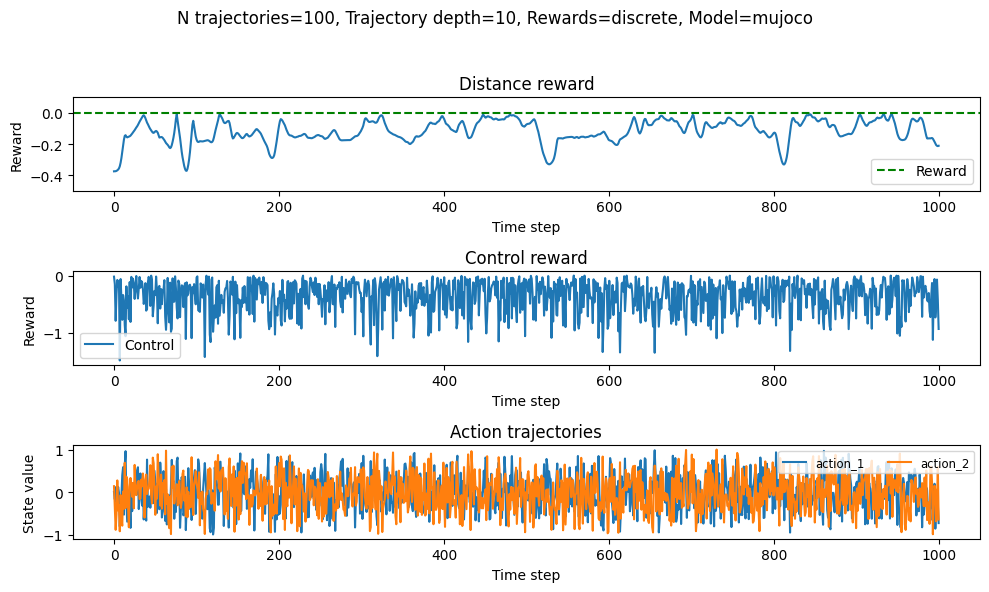

In [9]:
def simulate(bird, n_episodes, time_steps):
    """Simulate bird, possibly episodic SARSA."""

    simulation_data = {}

    for epi in range(n_episodes):
        episode_seed = 54 + epi
        np.random.seed(episode_seed)

        env = gym.make("Reacher-v5", render_mode="rgb_array") 
        obs, _ = env.reset(seed=episode_seed)

        writer = imageio.get_writer("output.gif", fps=30)

        obs_dim = env.observation_space.shape[0]
        act_dim = env.action_space.shape[0]

        observations = np.zeros((time_steps, obs_dim))
        actions = np.zeros((time_steps, act_dim))
        rewards = np.zeros(time_steps)

        # We'll initialize reward components later after the first env.step() gives us `info`
        reward_components = {}
        reward_names = None

        observations[0] = obs  # store initial observation at time 0

        for t in range(time_steps):
            action = bird.mujoco_policy(env, obs)
            action = np.asarray(action).flatten()
            actions[t] = action

            obs, reward, done, truncated, info = env.step(action)
            observations[t] = obs
            rewards[t] = reward

            # Initialize reward_components dict once we see the reward names
            if t == 0 and info:
                reward_names = list(info.keys())
                reward_components = {
                    name: np.zeros(time_steps) for name in reward_names
                }

            # Record reward components if they exist
            for name in reward_components:
                reward_components[name][t] = info.get(name, 0.0)

            if epi == n_episodes - 1:
                frame = env.render()
                writer.append_data(np.asarray(frame).astype(np.uint8))

        writer.close()
        env.close()

        episode_data = {}

        for i in range(obs_dim):
            episode_data[f"state_{i+1}"] = observations[:, i]
        for i in range(act_dim):
            episode_data[f"action_{i+1}"] = actions[:, i]

        episode_data["reward"] = rewards
        for name, values in reward_components.items():
            episode_data[f"reward_{name}"] = values
        episode_data["reward_names"] = reward_names

        simulation_data[f"episode_{epi+1}"] = episode_data

    return simulation_data


# Simulate the bird
planning_width = 100 # how many trajectories to simulate
n_planning = 10 # how deep the rolout of each trajectory is
reward_type='discrete' # rewards can be 'discrete' or 'continuous'
model_type='mujoco' # model can be 'mujoco' or 'linear_full' or 'linear_reduced_<int>' where <int> is the rank of the model

bird = MPCShittyBird(n_actions = 10, planning_width=planning_width, n_planning=n_planning, reward_type=reward_type, model_type=model_type) 

# Simulate the bird
simulation_data = simulate(bird, n_episodes=1, time_steps=1000)

episode1 = simulation_data["episode_1"]

distance_reward = episode1["reward_reward_dist"]
control_reward = episode1["reward_reward_ctrl"]

plt.figure(figsize=(10, 6))
plt.suptitle(f'N trajectories={planning_width}, Trajectory depth={n_planning}, Rewards={reward_type}, Model={model_type}', fontsize=12)

# 1. Distance reward
plt.subplot(3, 1, 1)
plt.plot(distance_reward)
plt.title('Distance reward')
plt.xlabel('Time step')
plt.ylabel('Reward')
plt.axhline(0, color='green', linestyle='--',label='Reward')
plt.ylim(-0.5, 0.1)
plt.legend()

# 2. Control reward
plt.subplot(3, 1, 2)
plt.plot(control_reward)
plt.title('Control reward')
plt.xlabel('Time step')
plt.ylabel('Reward')
plt.legend(['Control'])

# 3. Plot state_1 to state_7
plt.subplot(3, 1, 3)
for i in range(1, 3):  # state_1 to state_7
    state = episode1[f"action_{i}"]  # assumed shape: (time_steps,)
    plt.plot(state, label=f'action_{i}')
plt.title('Action trajectories')
plt.xlabel('Time step')
plt.ylabel('State value')
plt.legend(ncol=2, fontsize='small', loc='upper right')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

